In [1]:
import tensorflow as tf
from tensorflow import keras
import os
import pandas as pd
from tensorflow.keras.applications import ResNet50V2
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PATH = 'datasets/ISIC_2020_corrected'
os.listdir(PATH)

['multiclass',
 'subset.csv',
 'test_split.csv',
 'train',
 'train.csv',
 'train_resized',
 'train_sd_split.csv',
 'train_split.csv',
 'val_split.csv']

In [3]:
train = pd.read_csv(f'{PATH}/train_split.csv')
val = pd.read_csv(f'{PATH}/val_split.csv')
test = pd.read_csv(f'{PATH}/test_split.csv')
train.shape, val.shape

((23188, 9), (4969, 9))

In [4]:
train.head()

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_6828587,IP_7403252,IL_9414338,male,45.0,lower extremity,nevus,benign,0
1,ISIC_6555618,IP_6538458,IL_7328536,female,50.0,head/neck,unknown,benign,0
2,ISIC_4407024,IP_4050705,IL_3085841,female,40.0,lower extremity,unknown,benign,0
3,ISIC_5329118,IP_4277352,IL_6163665,female,40.0,torso,nevus,benign,0
4,ISIC_0779135,IP_4938349,IL_4355710,male,70.0,head/neck,unknown,benign,0


In [6]:
BATCH_SIZE = 64
AUTO = tf.data.experimental.AUTOTUNE

def decode(name, label):
    img = tf.io.read_file(name)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.cast(img, tf.float32)
    return img, label
    
def load_ds(df):
    options = tf.data.Options()
    options.experimental_deterministic = False
    imgs, labels = df["image_name"].values, df["target"].values
    imgs = [f'{PATH}/train_resized/{name}.jpg' for name in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    ds = ds.with_options(options)
    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.cache()
    ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTO)
    return ds

In [7]:
train_ds = load_ds(train)
val_ds = load_ds(val)
test_ds = load_ds(test)

In [8]:
IMAGE_SIZE = (256, 256, 3)

encoder = ResNet50V2(
    include_top=False,
    input_shape=IMAGE_SIZE,
    weights='imagenet'
)
encoder.trainable = False

inputs = keras.Input(shape=IMAGE_SIZE)
x = keras.layers.Rescaling(1./255)(inputs)
x = encoder(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 256, 256, 3)       0         
                                                                 
 resnet50v2 (Functional)     (None, 8, 8, 2048)        23564800  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 1)                 2049      
                                                                 
Total params: 23,566,849
Trainable params: 2,049
Non-trainable params: 23,564,800
_____________________________________________

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(name="auc-ROC", curve='ROC'), keras.metrics.AUC(name="auc-PR", curve='PR')]
)

In [10]:
filepath = 'models/checkpoints/baseline2'
cb = tf.keras.callbacks.ModelCheckpoint(
    filepath = filepath,
    monitor="val_auc-ROC",
    verbose=0,
    save_best_only=True,
    save_weights_only=True,
    mode="max"
)

In [11]:
history = model.fit(train_ds,
                    epochs=10,
                    validation_data=val_ds,
                    #validation_steps=10,
                    callbacks=[cb]
                   )

Epoch 1/10
363/363 [==============================] - 92s 228ms/step - loss: 0.1052 - auc-ROC: 0.6013 - auc-PR: 0.0285 - val_loss: 0.0779 - val_auc-ROC: 0.7895 - val_auc-PR: 0.1163
Epoch 2/10
363/363 [==============================] - 77s 212ms/step - loss: 0.0753 - auc-ROC: 0.8081 - auc-PR: 0.1174 - val_loss: 0.0729 - val_auc-ROC: 0.8547 - val_auc-PR: 0.1706
Epoch 3/10
363/363 [==============================] - 77s 212ms/step - loss: 0.0716 - auc-ROC: 0.8389 - auc-PR: 0.1566 - val_loss: 0.0710 - val_auc-ROC: 0.8524 - val_auc-PR: 0.1686
Epoch 4/10
363/363 [==============================] - 69s 189ms/step - loss: 0.0693 - auc-ROC: 0.8572 - auc-PR: 0.1720 - val_loss: 0.0705 - val_auc-ROC: 0.8603 - val_auc-PR: 0.1664
Epoch 5/10
363/363 [==============================] - 67s 183ms/step - loss: 0.0670 - auc-ROC: 0.8703 - auc-PR: 0.2065 - val_loss: 0.0704 - val_auc-ROC: 0.8609 - val_auc-PR: 0.1675
Epoch 6/10
363/363 [==============================] - 64s 176ms/step - loss: 0.0655 - auc-ROC: 

In [12]:
history.history

{'loss': [0.10522088408470154,
  0.07531087100505829,
  0.07155343145132065,
  0.06926003843545914,
  0.06699798256158829,
  0.06551489979028702,
  0.06381093710660934,
  0.06281702220439911,
  0.061553239822387695,
  0.060611870139837265],
 'auc-ROC': [0.6013309359550476,
  0.8081047534942627,
  0.8389151096343994,
  0.8572286367416382,
  0.8703064918518066,
  0.8794395327568054,
  0.8851490616798401,
  0.8921729326248169,
  0.9011636972427368,
  0.9051812887191772],
 'auc-PR': [0.028526153415441513,
  0.11739005148410797,
  0.15655110776424408,
  0.17198987305164337,
  0.20647405087947845,
  0.22735485434532166,
  0.2635321617126465,
  0.26757609844207764,
  0.2895713746547699,
  0.30698901414871216],
 'val_loss': [0.07789723575115204,
  0.07294150441884995,
  0.07095948606729507,
  0.07052268087863922,
  0.07035927474498749,
  0.07042455673217773,
  0.07082421332597733,
  0.07095534354448318,
  0.07113827019929886,
  0.07046099752187729],
 'val_auc-ROC': [0.7894771099090576,
  0.854

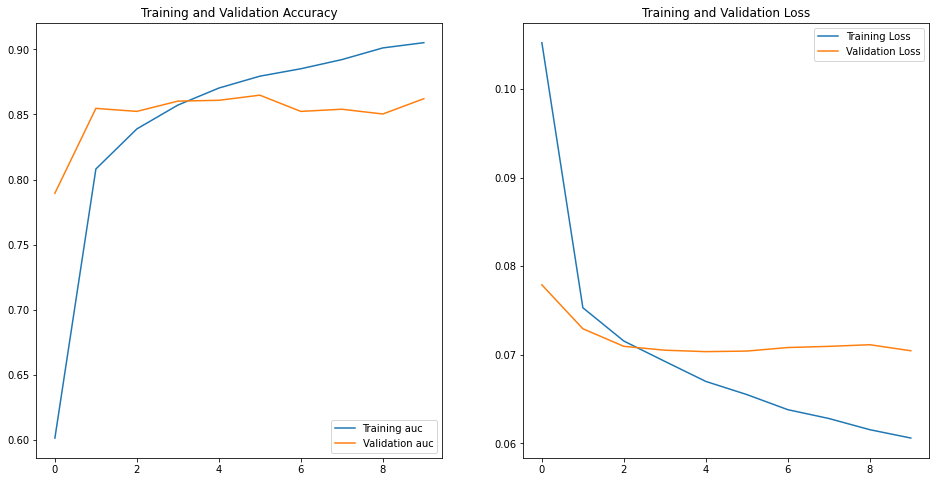

In [15]:
auc = history.history['auc-ROC']
val_auc = history.history['val_auc-ROC']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, auc, label='Training auc')
plt.plot(epochs_range, val_auc, label='Validation auc')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [18]:
model.load_weights(filepath)
results = model.evaluate(test_ds)
print(results)

78/78 [==============================] - 11s 139ms/step - loss: 0.0728 - auc-ROC: 0.8564 - auc-PR: 0.1141
[0.0727672204375267, 0.8564324975013733, 0.11413047462701797]


In [21]:
history.history['evaluation'] = results
history.history

{'loss': [0.12608055770397186,
  0.08349297195672989,
  0.11130350083112717,
  0.08301620930433273,
  0.07850052416324615,
  0.07594470679759979,
  0.0754527822136879,
  0.07115525007247925,
  0.06950052082538605,
  0.06650582700967789],
 'auc': [0.6173259019851685,
  0.7649521827697754,
  0.7744652032852173,
  0.7297800779342651,
  0.7993853688240051,
  0.8074852228164673,
  0.8147390484809875,
  0.8655700087547302,
  0.8577432632446289,
  0.8945533633232117],
 'false_negatives': [41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0,
  41.0],
 'true_positives': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'val_loss': [0.09472941607236862,
  0.084307461977005,
  0.059485454112291336,
  0.08389177918434143,
  0.08924411237239838,
  0.09721383452415466,
  0.10287590324878693,
  0.08853951841592789,
  0.08961668610572815,
  0.09985748678445816],
 'val_auc': [0.7143710255622864,
  0.8392221331596375,
  0.6352968215942383,
  0.7494580149650574,
  0.7030917406082153,


In [17]:

model.save('models/baseline2ROCPR.h5')